In [2]:
import numpy as np
import pandas as pd


In [5]:
df = pd.read_csv('/content/placement-dataset.csv')


In [6]:
df.head()

,city,cgpa,iq,placement
0,New York,6.8,123.0,1
1,Los Angeles,5.9,106.0,0
2,Chicago,NaN,121.0,0
3,New York,7.4,132.0,1
4,Los Angeles,5.8,142.0,0


In [7]:
df.shape

(100, 4)

#steps
# 0. preprocess + exploratory data analysis + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. train the model
# 5. Evalute the model/model selection
# 6. Deploy the model

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   city       100 non-null    object 
 1   cgpa       92 non-null     float64
 2   iq         96 non-null     float64
 3   placement  100 non-null    int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 3.3+ KB


In [9]:
df = df.iloc[:,1:]

In [10]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,NaN,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [11]:
import matplotlib.pyplot as plt

Handling Null Value

In [ ]:
for col in df.columns:
    if df[col].isna().sum()>0:
        df[col].fillna(value=df[col].mean(),inplace=True)

In [15]:
df.isna().sum()

,0
cgpa,0
iq,0
placement,0


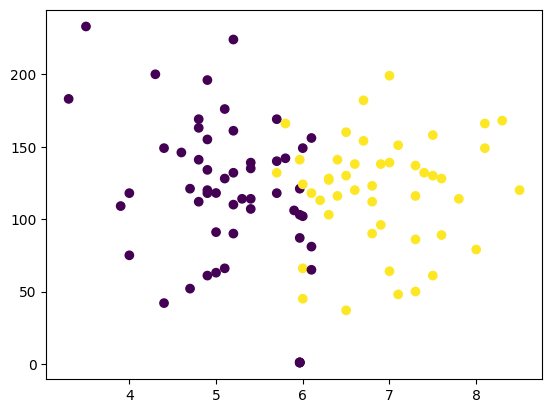

In [16]:
plt.scatter(df['cgpa'],df['iq'], c = df['placement'])

In [17]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [18]:
x

,cgpa,iq
0,6.800000,123.0
1,5.900000,106.0
2,5.965217,121.0
3,7.400000,132.0
4,5.800000,142.0
...,...,...
95,4.300000,200.0
96,4.400000,42.0
97,6.700000,182.0
98,6.300000,103.0


In [19]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


train and split

In [21]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.1)

scale the values

In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
scaler = StandardScaler()

In [27]:
x_train = scaler.fit_transform(x_train)

In [28]:
x_train

array([[-0.68847629, -0.18059581],
       [ 0.02866847,  0.65164657],
       [-0.59883319, -0.09523761],
       [-0.00251174, -0.32997264],
       [-0.24026081,  0.45959064],
       [ 1.19402869,  0.39557199],
       [-0.00251174,  0.05413922],
       [ 0.74581322, -0.60738677],
       [-0.5091901 ,  0.3528929 ],
       [ 1.19402869, -0.05255852],
       [-0.77811938,  1.22781437],
       [ 1.91117345,  0.65164657],
       [ 2.09045963,  1.05709799],
       [-0.95740557,  1.65460533],
       [ 0.65617013,  0.75834431],
       [-0.15061772,  1.01441889],
       [-1.49526413,  1.73996353],
       [-0.95740557,  0.03279968],
       [ 0.83545632,  0.41691154],
       [ 0.29759775,  0.20351606],
       [ 0.92509941,  1.71862398],
       [-0.00251174, -2.50660655],
       [-0.00251174,  0.48093019],
       [-0.24026081,  1.07843753],
       [ 0.65617013,  1.35585166],
       [ 0.38724084, -0.05255852],
       [ 1.0147425 , -1.50364779],
       [-0.86776247, -0.00987942],
       [ 0.47688394,

In [29]:
x_test = scaler.transform(x_test)

In [30]:
x_test

array([[ 1.37331488,  0.24619516],
       [ 0.11831156, -0.7994427 ],
       [-1.40562104, -1.63168508],
       [ 1.46295797, -0.62872632],
       [-1.40562104,  0.65164657],
       [-1.04704866,  0.48093019],
       [ 0.29759775,  0.18217651],
       [ 0.02866847, -0.35131219],
       [ 0.20795466, -0.11657716],
       [ 0.11831156,  0.80102341]])

In [31]:
from sklearn.linear_model import LogisticRegression

In [32]:
clf = LogisticRegression()

#model training

In [33]:
clf.fit(x_train,y_train)

LogisticRegression()

Evalute the model

In [36]:
y_pred = clf.predict(x_test)

In [37]:
y_test

,placement
83,1
78,0
96,0
42,1
88,0
51,0
70,1
62,0
99,1
8,0


In [38]:
from sklearn.metrics import accuracy_score

In [39]:
accuracy_score(y_test,y_pred)

0.9

visualize

In [40]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

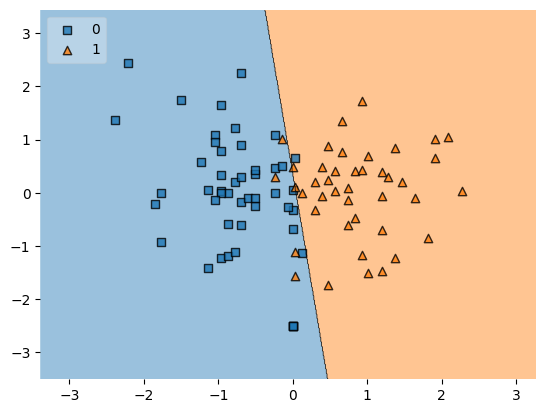

In [41]:
plot_decision_regions(x_train,y_train.values,clf=clf,legend=2)